In [ ]:
pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 76.5 MB/s eta 0:00:00


In [ ]:
import os
import torch
import numpy as np
from google.colab import drive

# Monto mi Google Drive para leer y guardar mis archivos
drive.mount('/content/drive')

# Asigno el dispositivo de hardware que Colab me proporciona
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo asignado: {dispositivo}")

# Defino mi panel de control maestro
ID_SUJETO = 3  # Cambio este valor para evaluar a otro paciente

NUM_CANALES = {1: 62, 2: 48, 3: 64}[ID_SUJETO]
NUM_WAVELETS = 40
NUM_DEDOS = 5
TAMANO_MUESTRA = 256

# Construyo el diccionario con la arquitectura de mi modelo
parametros_modelo = dict(
    canales=[64, 64, 128, 256, 512, 512],
    tamanos_kernel=[7, 5, 5, 3, 3],
    pasos=[2, 2, 2, 2, 2],
    dilatacion=[1, 2, 3, 1, 2],
    n_electrodos=NUM_CANALES,
    n_frecuencias=NUM_WAVELETS,
    n_canales_salida=NUM_DEDOS
)

# Establezco mis rutas de trabajo en Drive
RUTA_BASE = "/content/drive/MyDrive/datos ECoG"
RUTA_ETIQUETAS_REALES = "/content/drive/MyDrive/datos ECoG - Prueba Dg"
DIRECTORIO_DATOS = os.path.join(RUTA_BASE, f"datos_procesados_sub{ID_SUJETO}")
DIRECTORIO_CHECKPOINTS = os.path.join(DIRECTORIO_DATOS, "checkpoints")
os.makedirs(DIRECTORIO_CHECKPOINTS, exist_ok=True)

# Genero un nombre dinámico para mi archivo de guardado
# Unimos todos los numeros de los kernels con guiones bajos para crear un nombre unico
etiqueta_kernels = "_".join(map(str, parametros_modelo['tamanos_kernel']))
NOMBRE_CHECKPOINT = f"modelo_S{ID_SUJETO}_k{etiqueta_kernels}"

print(f"Entorno listo para el Sujeto {ID_SUJETO}. Mi modelo se guardará como: {NOMBRE_CHECKPOINT}.ckpt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dispositivo asignado: cuda
Entorno listo para el Sujeto 3. Mi modelo se guardará como: modelo_S3_k7_5_5_3_3.ckpt


In [ ]:
import scipy.io
import scipy.interpolate
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader

# Defino una función para interpolar y ajustar las frecuencias de mis etiquetas reales
def interpolar_etiquetas_reales(flexion_dedos, fs_actual=1000, fs_real=25, hz_necesarios=100):
    proporcion_reduccion = fs_actual // fs_real
    flexion_dedos_fs_real = flexion_dedos[:, ::proporcion_reduccion]
    flexion_dedos_fs_real = np.c_[flexion_dedos_fs_real, flexion_dedos_fs_real.T[-1]]
    proporcion_aumento = hz_necesarios // fs_real
    tiempos = np.asarray(range(flexion_dedos_fs_real.shape[1])) * proporcion_aumento
    funciones_flexion = [scipy.interpolate.interp1d(tiempos, canal_dedo, kind='cubic') for canal_dedo in flexion_dedos_fs_real]
    tiempos_hz_necesarios = np.asarray(range(flexion_dedos_fs_real.shape[1] * proporcion_aumento)[:-proporcion_aumento])
    return np.array([[func(t) for t in tiempos_hz_necesarios] for func in funciones_flexion])

# Creo mi clase Dataset para estructurar mis arreglos de Numpy
class ConjuntoDatosEcog(Dataset):
    def __init__(self, datos_ecog, datos_dedos, tamano_muestra):
        self.datos_ecog = datos_ecog
        self.datos_dedos = datos_dedos
        self.duracion = self.datos_ecog.shape[-1]
        self.tamano_muestra = tamano_muestra
        self.paso = 1
        self.longitud_ds = (self.duracion - self.tamano_muestra) // self.paso

    def __len__(self):
        return self.longitud_ds

    def __getitem__(self, indice):
        inicio = indice * self.paso
        fin = inicio + self.tamano_muestra
        return self.datos_ecog[..., inicio:fin], self.datos_dedos[..., inicio:fin]

# Configuro mi LightningDataModule para gestionar las fases de mis datos
class ModuloDatosEcog(pl.LightningDataModule):
    def __init__(self, tamano_muestra=TAMANO_MUESTRA, directorio_datos=DIRECTORIO_DATOS, tamano_lote=128, id_sujeto=ID_SUJETO):
        super().__init__()
        self.directorio_datos = directorio_datos
        self.tamano_muestra = tamano_muestra
        self.tamano_lote = tamano_lote
        self.id_sujeto = id_sujeto

    def setup(self, stage=None):
        if stage is None or stage == "fit":
            ruta_ecog_train = os.path.join(self.directorio_datos, "train", f"ecog_data_sub{self.id_sujeto}.npy")
            ruta_dedos_train = os.path.join(self.directorio_datos, "train", f"dedos_data_sub{self.id_sujeto}.npy")

            ecog_completo = np.load(ruta_ecog_train).astype('float32')
            dedos_completo = np.load(ruta_dedos_train).astype('float32')

            # Divido mis datos en 80% entrenamiento y 20% validacion
            indice_div = int(ecog_completo.shape[-1] * 0.8)

            self.x_val = ecog_completo[..., indice_div:]
            self.y_val = dedos_completo[..., indice_div:]

            self.entrenamiento = ConjuntoDatosEcog(ecog_completo[..., :indice_div], dedos_completo[..., :indice_div], self.tamano_muestra)
            self.validacion = ConjuntoDatosEcog(self.x_val, self.y_val, self.tamano_muestra)

        if stage is None or stage == "test":
            ruta_ecog_test = os.path.join(self.directorio_datos, "test", f"ecog_data_sub{self.id_sujeto}.npy")
            ruta_dedos_test = os.path.join(RUTA_ETIQUETAS_REALES, f"reales_sub{self.id_sujeto}_test.npy")

            print(f"Preparando etiquetas reales del Sujeto {self.id_sujeto}...")
            ruta_mat = os.path.join(RUTA_ETIQUETAS_REALES, f"sub{self.id_sujeto}_testlabels.mat")
            datos_mat = scipy.io.loadmat(ruta_mat)
            reales_crudos = datos_mat['test_dg'].astype('float64').T
            reales_interpolados = interpolar_etiquetas_reales(reales_crudos)
            np.save(ruta_dedos_test, reales_interpolados)

            self.x_test = np.load(ruta_ecog_test).astype('float32')
            self.y_test = np.load(ruta_dedos_test).astype('float32')

            # Aseguro que mis dimensiones de entrada y salida coincidan perfectamente
            longitud_minima = min(self.x_test.shape[-1], self.y_test.shape[-1])
            self.x_test = self.x_test[..., :longitud_minima]
            self.y_test = self.y_test[..., :longitud_minima]

            self.prueba = ConjuntoDatosEcog(self.x_test, self.y_test, self.tamano_muestra)

    def train_dataloader(self):
        return DataLoader(self.entrenamiento, batch_size=self.tamano_lote, num_workers=2, shuffle=True)
    def val_dataloader(self):
        return DataLoader(self.validacion, batch_size=self.tamano_lote, num_workers=2)
    def test_dataloader(self):
        return DataLoader(self.prueba, batch_size=self.tamano_lote, num_workers=2)

print("Modulo de Datos programado exitosamente.")

Modulo de Datos programado exitosamente.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Defino mis funciones matemáticas de métricas
def metrica_correlacion_coseno(x, y):
    return torch.mean(nn.CosineSimilarity(dim=-1, eps=1e-08)(x, y))

def metrica_correlacion_pearson(x, y):
    return np.corrcoef(x, y)[0, 1]

# Construyo mi bloque de compresión (Encoder)
class BloqueConv(nn.Module):
    def __init__(self, canales_entrada, canales_salida, tamano_kernel, paso=1, dilatacion=1, drop_prob=0.3):
        super().__init__()
        self.conv1d = nn.Conv1d(canales_entrada, canales_salida, kernel_size=tamano_kernel, stride=1, dilation=dilatacion, padding='same', bias=False)
        self.normalizacion = nn.LayerNorm(canales_salida)
        self.activacion = nn.GELU()
        self.dropout = nn.Dropout(p=drop_prob)
        self.reduccion = nn.MaxPool1d(kernel_size=paso, stride=paso)

    def forward(self, x):
        x = self.conv1d(x)
        x = torch.transpose(x, -2, -1)
        x = self.normalizacion(x)
        x = torch.transpose(x, -2, -1)
        return self.reduccion(self.dropout(self.activacion(x)))

# Construyo mi bloque de expansión (Decoder)
class BloqueConvArriba(nn.Module):
    def __init__(self, escala, canales_entrada, canales_salida, tamano_kernel):
        super().__init__()
        self.conv_transpuesta = nn.ConvTranspose1d(canales_entrada, canales_salida, kernel_size=tamano_kernel, stride=escala, padding=(tamano_kernel - escala) // 2, output_padding=0)
        self.normalizacion = nn.LayerNorm(canales_salida)
        self.activacion = nn.GELU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.conv_transpuesta(x)
        x = torch.transpose(x, -2, -1)
        x = self.normalizacion(x)
        x = torch.transpose(x, -2, -1)
        return self.dropout(self.activacion(x))

# Ensamblo mi red AutoCodificadora completa
class AutoCodificador1D(nn.Module):
    def __init__(self, n_electrodos, n_frecuencias, n_canales_salida, canales, tamanos_kernel, pasos, dilatacion):
        super().__init__()
        self.profundidad = len(canales) - 1

        self.reduccion_espacial = BloqueConv(n_frecuencias * n_electrodos, canales[0], tamano_kernel=3)

        self.bloques_reduccion = nn.ModuleList([
            BloqueConv(canales[i], canales[i+1], tamanos_kernel[i], paso=pasos[i], dilatacion=dilatacion[i])
            for i in range(self.profundidad)
        ])

        self.bloques_aumento = nn.ModuleList([
            BloqueConvArriba(escala=pasos[i], canales_entrada=canales[i+1] if i == self.profundidad-1 else canales[i+1]*2, canales_salida=canales[i], tamano_kernel=tamanos_kernel[i])
            for i in range(self.profundidad-1, -1, -1)
        ])

        self.conv_final = nn.Conv1d(canales[0]*2, n_canales_salida, kernel_size=1, padding='same')

    def forward(self, x):
        lote, elec, n_frec, tiempo = x.shape
        x = self.reduccion_espacial(x.reshape(lote, -1, tiempo))

        conexiones_salto = []
        for i in range(self.profundidad):
            conexiones_salto.append(x)
            x = self.bloques_reduccion[i](x)

        for i in range(self.profundidad):
            x = self.bloques_aumento[i](x)
            salto = conexiones_salto[-1 - i]

            # Aplico mi solucion de padding dinámico
            diferencia = salto.shape[-1] - x.shape[-1]
            if diferencia != 0:
                x = F.pad(x, (0, diferencia))

            x = torch.cat((x, salto), dim=1)

        return self.conv_final(x)

print("Arquitectura de Red compilada.")

Arquitectura de Red compilada.


In [ ]:
import matplotlib.pyplot as plt
import scipy.ndimage
from pytorch_lightning.callbacks import Callback
import plotly.tools as tls
import wandb
import numpy as np
import torch
import torch.nn.functional as F

# Configuro la envoltura de mi modelo para PyTorch Lightning
class ModeloBaseEcog(pl.LightningModule):
    def __init__(self, modelo):
        super().__init__()
        self.modelo = modelo
        self.tasa_aprendizaje = 8.42e-5

    def training_step(self, lote, indice_lote):
        x, y = lote
        y_predicho = self.modelo(x)
        perdida = F.mse_loss(y_predicho, y)
        corr = metrica_correlacion_coseno(y_predicho, y)
        self.log("train_loss", perdida, on_epoch=True)
        self.log("cosine_dst_train", corr, on_epoch=True)
        return 0.5 * perdida + 0.5 * (1. - corr)

    def validation_step(self, lote, indice_lote):
        x, y = lote
        y_predicho = self.modelo(x)
        self.log("val_loss", F.mse_loss(y_predicho, y), on_epoch=True)
        return y_predicho

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.tasa_aprendizaje, weight_decay=1e-4)

# Defino mi sistema de evaluacion y visualizacion corregido
class CallbackEvaluacion(Callback):
    def __init__(self, val_x, val_y, num_dedos, fase="Validacion"):
        super().__init__()
        # Mantengo la forma original de x (Canales, Wavelets, Tiempo)
        self.val_x = val_x
        # val_y es un arreglo de Numpy, asi que el uso de .T es perfectamente valido y seguro aqui
        self.val_y = val_y.T
        self.num_dedos = num_dedos
        self.fase = fase

    def procesar_evaluacion(self, pl_module):
        # Calculo el limite basandome en la ultima dimension (tiempo)
        limite = self.val_x.shape[-1] // 64 * 64

        # APLICO LA CORRECCION: Corto directamente el tiempo y lo convierto a tensor sin usar .T
        x_lote_np = self.val_x[..., :limite]
        x_lote = torch.from_numpy(x_lote_np).float().to(pl_module.device)

        # Agrego la dimension del lote al principio del tensor
        x_lote = torch.unsqueeze(x_lote, 0)

        y_pred = pl_module.modelo(x_lote)[0].cpu().detach().numpy()
        y_pred_suave = scipy.ndimage.gaussian_filter1d(y_pred, sigma=6 if self.fase == "Validacion" else 1, axis=1)
        y_real = self.val_y[:limite]

        figura, ejes = plt.subplots(self.num_dedos // 2, self.num_dedos - self.num_dedos // 2, figsize=(15, 12))
        correlaciones = []

        for roi in range(self.num_dedos):
            y_p, y_r = y_pred_suave.T[:, roi], y_real[:, roi]
            corr = metrica_correlacion_pearson(y_p, y_r)
            correlaciones.append(corr)

            eje = ejes.flat[roi]
            eje.plot(y_p, label='Prediccion')
            eje.plot(y_r, label='Real')
            eje.set_title(f"Dedo {roi} - Correlacion: {corr:.2f}")

        media_correlacion = np.mean(correlaciones)

        if self.fase == "Validacion":
            pl_module.log("corr_mean_val", media_correlacion, on_epoch=True)
            try:
                wandb.log({"graficos": wandb.Image(figura)})
            except:
                pass
            plt.close(figura)
        else:
            # Guardo la prediccion final
            import os
            DIRECTORIO_DATOS = "/content/drive/MyDrive/datos ECoG/datos_procesados_sub3"
            np.save(os.path.join(DIRECTORIO_DATOS, "prediccion_final.npy"), y_pred_suave.T)
            print(f"Correlacion Media de Prueba: {media_correlacion:.4f}")
            tls.mpl_to_plotly(figura).write_html(os.path.join(DIRECTORIO_DATOS, "resultados_prueba.html"))

    def on_validation_epoch_end(self, trainer, pl_module):
        with torch.no_grad():
            self.procesar_evaluacion(pl_module)

class CallbackPruebaReal:
    def __init__(self, test_x, test_y, num_dedos):
        self.evaluador = CallbackEvaluacion(test_x, test_y, num_dedos, fase="Prueba")

    def evaluar(self, pl_module):
        dispositivo_actual = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        with torch.no_grad():
            self.evaluador.procesar_evaluacion(pl_module.to(dispositivo_actual))

print("Callbacks preparados.")

Callbacks preparados.


In [ ]:
from sklearn.model_selection import KFold
from pytorch_lightning import Trainer
from torch.utils.data import DataLoader
import numpy as np

print("Iniciando configuracion para Validacion Cruzada K-Folds del AutoCodificador...")

# Defino la cantidad de divisiones para mis datos
K_PLIEGUES = 5
kfold = KFold(n_splits=K_PLIEGUES, shuffle=True, random_state=42)

# 1. Cargo todos los datos de entrenamiento directamente
ruta_ecog_train = os.path.join(DIRECTORIO_DATOS, "train", f"ecog_data_sub{ID_SUJETO}.npy")
ruta_dedos_train = os.path.join(DIRECTORIO_DATOS, "train", f"dedos_data_sub{ID_SUJETO}.npy")

ecog_completo = np.load(ruta_ecog_train).astype('float32')
dedos_completo = np.load(ruta_dedos_train).astype('float32')

# Como mis datos tienen la forma (Canales, Wavelets, Tiempo), extraigo el limite temporal
tiempo_total = ecog_completo.shape[-1]
indices_tiempo = np.arange(tiempo_total)

resultados_correlacion = []

print(f"Iniciando entrenamiento con {K_PLIEGUES} pliegues.")

for fold, (indices_train, indices_val) in enumerate(kfold.split(indices_tiempo)):
    print(f"\n--- Iniciando Vuelta {fold + 1} de {K_PLIEGUES} ---")

    # 2. Corto los datos temporalmente usando los indices exactos de esta vuelta
    x_train_fold = np.take(ecog_completo, indices_train, axis=-1)
    y_train_fold = np.take(dedos_completo, indices_train, axis=-1)

    x_val_fold = np.take(ecog_completo, indices_val, axis=-1)
    y_val_fold = np.take(dedos_completo, indices_val, axis=-1)

    # 3. Empaqueto los datos cortados utilizando mi clase ConjuntoDatosEcog
    dataset_train = ConjuntoDatosEcog(x_train_fold, y_train_fold, TAMANO_MUESTRA)
    dataset_val = ConjuntoDatosEcog(x_val_fold, y_val_fold, TAMANO_MUESTRA)

    # Creo los DataLoaders manualmente para esta iteracion
    loader_train = DataLoader(dataset_train, batch_size=128, num_workers=2, shuffle=True)
    loader_val = DataLoader(dataset_val, batch_size=128, num_workers=2)

    # 4. Instancio un modelo completamente nuevo
    # Esto es critico para asegurar que el modelo no recuerde nada de la vuelta anterior
    modelo_principal = AutoCodificador1D(**parametros_modelo)
    envoltura_lightning = ModeloBaseEcog(modelo_principal)

    # 5. Configuro el entrenador para este pliegue
    # Desactivo wandb y el guardado de checkpoints para no sobrescribir archivos ni saturar la memoria
    entrenador = Trainer(
        accelerator="auto",
        devices=1,
        max_epochs=15,
        enable_checkpointing=False,
        logger=False,
        callbacks=[CallbackEvaluacion(x_val_fold, y_val_fold, NUM_DEDOS, fase="Validacion")]
    )

    # 6. Ejecuto el entrenamiento usando mis DataLoaders especificos
    entrenador.fit(envoltura_lightning, train_dataloaders=loader_train, val_dataloaders=loader_val)

    # 7. Extraigo la mejor correlacion obtenida en la validacion de esta vuelta
    corr_final = entrenador.logged_metrics.get("corr_mean_val")

    if corr_final is not None:
        valor_corr = corr_final.item()
        print(f"Correlacion final en Vuelta {fold + 1}: {valor_corr:.4f}")
        resultados_correlacion.append(valor_corr)
    else:
        print(f"No se detecto el registro de correlacion en la vuelta {fold + 1}")

# 8. Reporte final del rendimiento real del AutoCodificador
if resultados_correlacion:
    promedio_final = np.mean(resultados_correlacion)
    print(f"\n--- REPORTE FINAL DE VALIDACION CRUZADA ({K_PLIEGUES}-FOLD) ---")
    print(f"Correlaciones por vuelta: {[f'{c:.4f}' for c in resultados_correlacion]}")
    print(f"Rendimiento global del AutoCodificador: {promedio_final:.4f}")

Iniciando configuracion para Validacion Cruzada K-Folds del AutoCodificador...
Iniciando entrenamiento con 5 pliegues.

--- Iniciando Vuelta 1 de 5 ---


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name   ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ modelo │ AutoCodificador1D │  4.0 M │ train │     0 │
└───┴────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.0 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 65                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

┏━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name   ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ modelo │ AutoCodificador1D │  4.0 M │ train │     0 │
└───┴────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.0 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 65                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


Correlacion final en Vuelta 5: 0.6708

--- REPORTE FINAL DE VALIDACION CRUZADA (5-FOLD) ---
Correlaciones por vuelta: ['0.7120', '0.6773', '0.7178', '0.7021', '0.6708']
Rendimiento global del AutoCodificador: 0.6960


In [ ]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import WandbLogger

# Instancio y preparo mis datos
modulo_datos = ModuloDatosEcog()
modulo_datos.setup()

# Construyo mi modelo y su envoltura usando mi diccionario de parametros
modelo_principal = AutoCodificador1D(**parametros_modelo)
envoltura_lightning = ModeloBaseEcog(modelo_principal)

print("Conectando con Weights & Biases...")
wandb.init(project="BCI_comp1")
registrador_wandb = WandbLogger()

# Configuro el mecanismo de guardado de mi modelo
callback_guardado = ModelCheckpoint(
    save_top_k=1,
    monitor="corr_mean_val",
    mode="max",
    dirpath=DIRECTORIO_CHECKPOINTS,
    filename=NOMBRE_CHECKPOINT
)

# Establezco mi condicion de parada temprana
parada_temprana = EarlyStopping(monitor="corr_mean_val", patience=8, mode="max")

# Preparo a mi entrenador
entrenador = Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=30,
    logger=registrador_wandb,
    callbacks=[
        CallbackEvaluacion(modulo_datos.x_val, modulo_datos.y_val, NUM_DEDOS),
        callback_guardado,
        parada_temprana
    ]
)

print("Iniciando fase de entrenamiento...")
entrenador.fit(envoltura_lightning, modulo_datos)
wandb.finish()

print("Iniciando fase de prueba con datos reales...")
modulo_datos.setup(stage="test")

# Recupero exactamente el mejor modelo que acabo de guardar
ruta_exacta = os.path.join(DIRECTORIO_CHECKPOINTS, f"{NOMBRE_CHECKPOINT}.ckpt")
modelo_entrenado = ModeloBaseEcog.load_from_checkpoint(
    checkpoint_path=ruta_exacta,
    modelo=AutoCodificador1D(**parametros_modelo)
)

# Ejecuto mi evaluacion final
evaluador_prueba = CallbackPruebaReal(modulo_datos.x_test, modulo_datos.y_test, NUM_DEDOS)
evaluador_prueba.evaluar(modelo_entrenado)
print("Entrenamiento y evaluacion finalizados.")

Preparando etiquetas reales del Sujeto 3...
Conectando con Weights & Biases...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loggers/wandb.py:400: UserWarning:

There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.



Iniciando fase de entrenamiento...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/drive/MyDrive/datos ECoG/datos_procesados_sub3/checkpoints exists and is not empty.

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name   ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ modelo │ AutoCodificador1D │  4.0 M │ train │     0 │
└───┴────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.0 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 65                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

corr_mean_val,▁▂▄▆▇▇▇██████▇███▇▇██
cosine_dst_train_epoch,▁▄▆▆▇▇▇▇█████████████
cosine_dst_train_step,▁▂▂▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██████████████████▇█
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇██████
train_loss_epoch,█▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_step,█▇▆▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇██
val_loss,█▆▅▄▂▂▂▁▂▁▁▁▁▁▁▂▁▁▁▁▁
corr_mean_val,0.75011
cosine_dst_train_epoch,0.99344
cosine_dst_train_step,0.99326


Iniciando fase de prueba con datos reales...
Preparando etiquetas reales del Sujeto 3...
Correlacion Media de Prueba: 0.5025
Entrenamiento y evaluacion finalizados.


Iniciando extraccion de caracteristicas latentes...
Dimensiones de los datos extraidos: (59212, 4096)
Ejecutando algoritmo K-Means con 5 clusters...
Reduciendo dimensiones con t-SNE para visualizacion (esto puede tomar un par de minutos)...


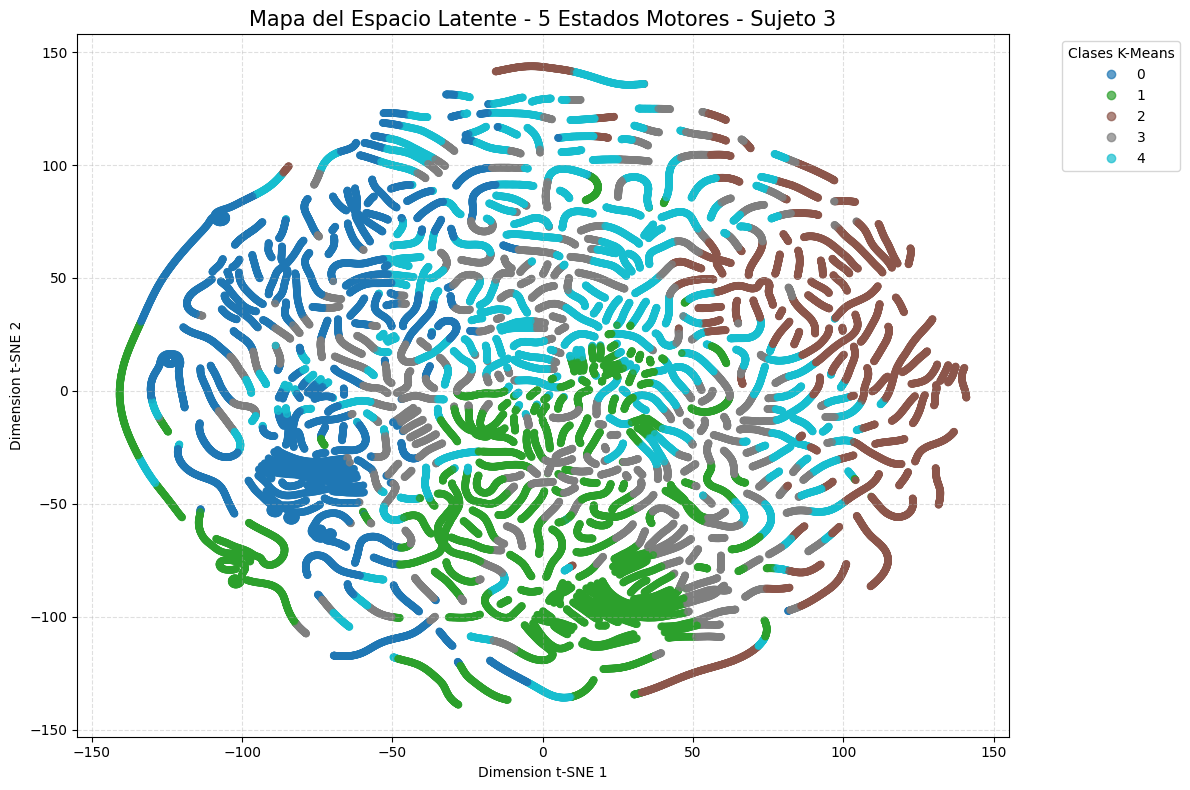

Proceso de agrupamiento completado exitosamente.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

print("Iniciando extraccion de caracteristicas latentes...")

# Preparo un diccionario con todos mis conjuntos de datos
dataloaders = {
    "Train": modulo_datos.train_dataloader(),
    "Val": modulo_datos.val_dataloader(),
    "Test": modulo_datos.test_dataloader()
}

caracteristicas_latentes = []

# Muevo mi modelo al dispositivo correcto y lo pongo en modo evaluacion
modelo_entrenado.eval()
modelo_entrenado.to(dispositivo)

# Extraigo la informacion procesada hasta el centro exacto de mi red
with torch.no_grad():
    for nombre_conjunto, dl in dataloaders.items():
        for lote_x, _ in dl:
            # Reestructuro la entrada de forma segura usando reshape
            lote_x = lote_x.to(dispositivo)
            b, e, w, t = lote_x.size()
            x = lote_x.reshape(b, e * w, t)

            # Paso los datos por la reduccion espacial
            x = modelo_entrenado.modelo.reduccion_espacial(x)

            # Paso los datos por todos los bloques del encoder
            for bloque in modelo_entrenado.modelo.bloques_reduccion:
                x = bloque(x)

            # APLICO LA SOLUCION: Uso reshape en lugar de view para evitar el error de memoria no contigua
            x_aplanado = x.reshape(x.size(0), -1).cpu().numpy()
            caracteristicas_latentes.append(x_aplanado)

# Uno todos los lotes en una matriz gigante
X_final = np.vstack(caracteristicas_latentes)
print(f"Dimensiones de los datos extraidos: {X_final.shape}")

# APLICO EL CAMBIO TEORICO: Ajusto K-Means a 5 clases, representando los 5 dedos
print("Ejecutando algoritmo K-Means con 5 clusters...")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_predichos = kmeans.fit_predict(X_final)

print("Reduciendo dimensiones con t-SNE para visualizacion (esto puede tomar un par de minutos)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_final)

# Ploteo mis resultados
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_predichos, cmap='tab10', alpha=0.7, s=20)
plt.title(f"Mapa del Espacio Latente - 5 Estados Motores - Sujeto {ID_SUJETO}", fontsize=15)
plt.xlabel("Dimension t-SNE 1")
plt.ylabel("Dimension t-SNE 2")
plt.legend(*scatter.legend_elements(), title="Clases K-Means", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Proceso de agrupamiento completado exitosamente.")